In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns4

In [96]:
n = pd.read_csv("processed_names.csv",names = ['names'],header=0)
names = n['names'].tolist()
a = ['.']+sorted(set(''.join(names)))

stoi = {}
itos = {}
for i1,c1 in enumerate(a):
  stoi[c1] = i1
  itos[i1] = c1
  
count_tensor = torch.zeros((27,27),dtype = torch.int32)
for name in names:
  name = ['.']+list(name.lower())+['.']
  for ch1,ch2 in zip(name,name[1:]):
    count_tensor[stoi[ch1],stoi[ch2]] += 1

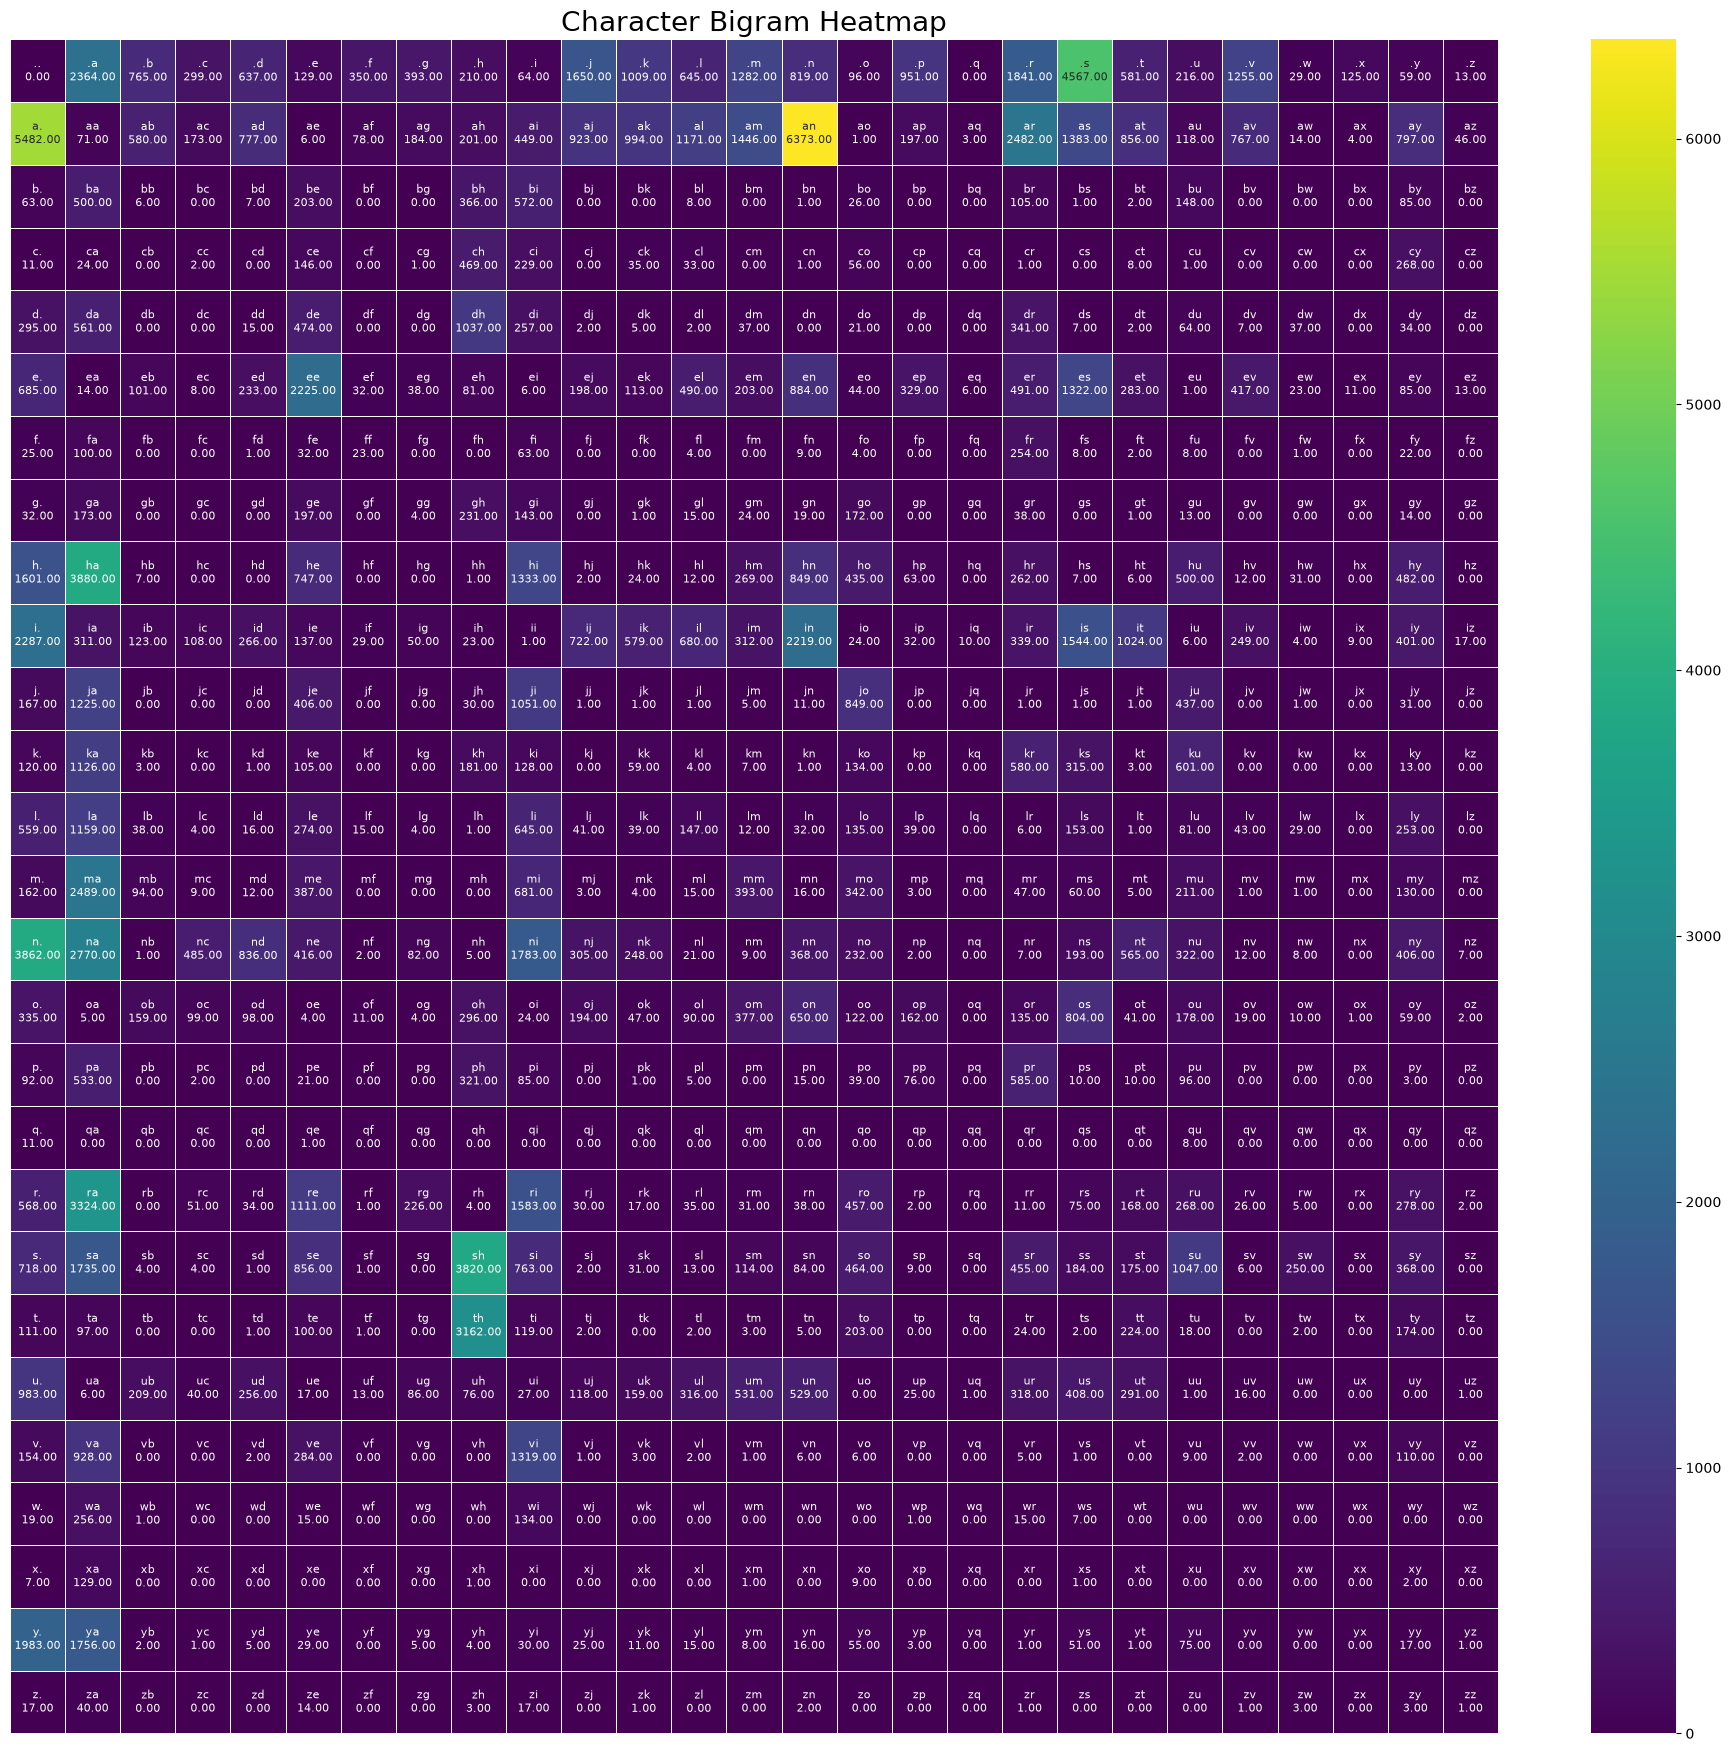

In [97]:
tensor_data = count_tensor.detach().cpu().numpy()

# Dummy itos mapping (e.g., 0='.', 1='a' through 26='z')
import string
itos = {0: '.'}
for i, char in enumerate(string.ascii_lowercase):
    itos[i+1] = char

# 2. Create the custom annotation array
# This will be a 27x27 array of strings formatted exactly how you want
annotations = np.empty((27, 27), dtype=object)

for i in range(27):
    for j in range(27):
        char_pair = f"{itos[i]}{itos[j]}"     # Example: "ab"
        val = tensor_data[i, j]               # Example: 0.4567...

        # Combine them with a newline (\n) and round the value to 2 decimals
        annotations[i, j] = f"{char_pair}\n{val:.2f}"

# 3. Set up the figure (made slightly larger to fit the extra text)
plt.figure(figsize=(24, 22))

# 4. Plot the heatmap
sns4.heatmap(tensor_data,
            annot=annotations,
            fmt="",                 # IMPORTANT: Must be empty string for custom text
            cmap="viridis",
            linewidths=0.5,
            xticklabels = False,
            yticklabels = False,
            annot_kws={"size": 8})  # Shrinks the font slightly to fit the boxes

# 5. Add labels
plt.title("Character Bigram Heatmap", fontsize=20)

plt.show()

In [98]:
P = count_tensor.float()
P /= P.sum(1,keepdim=True)

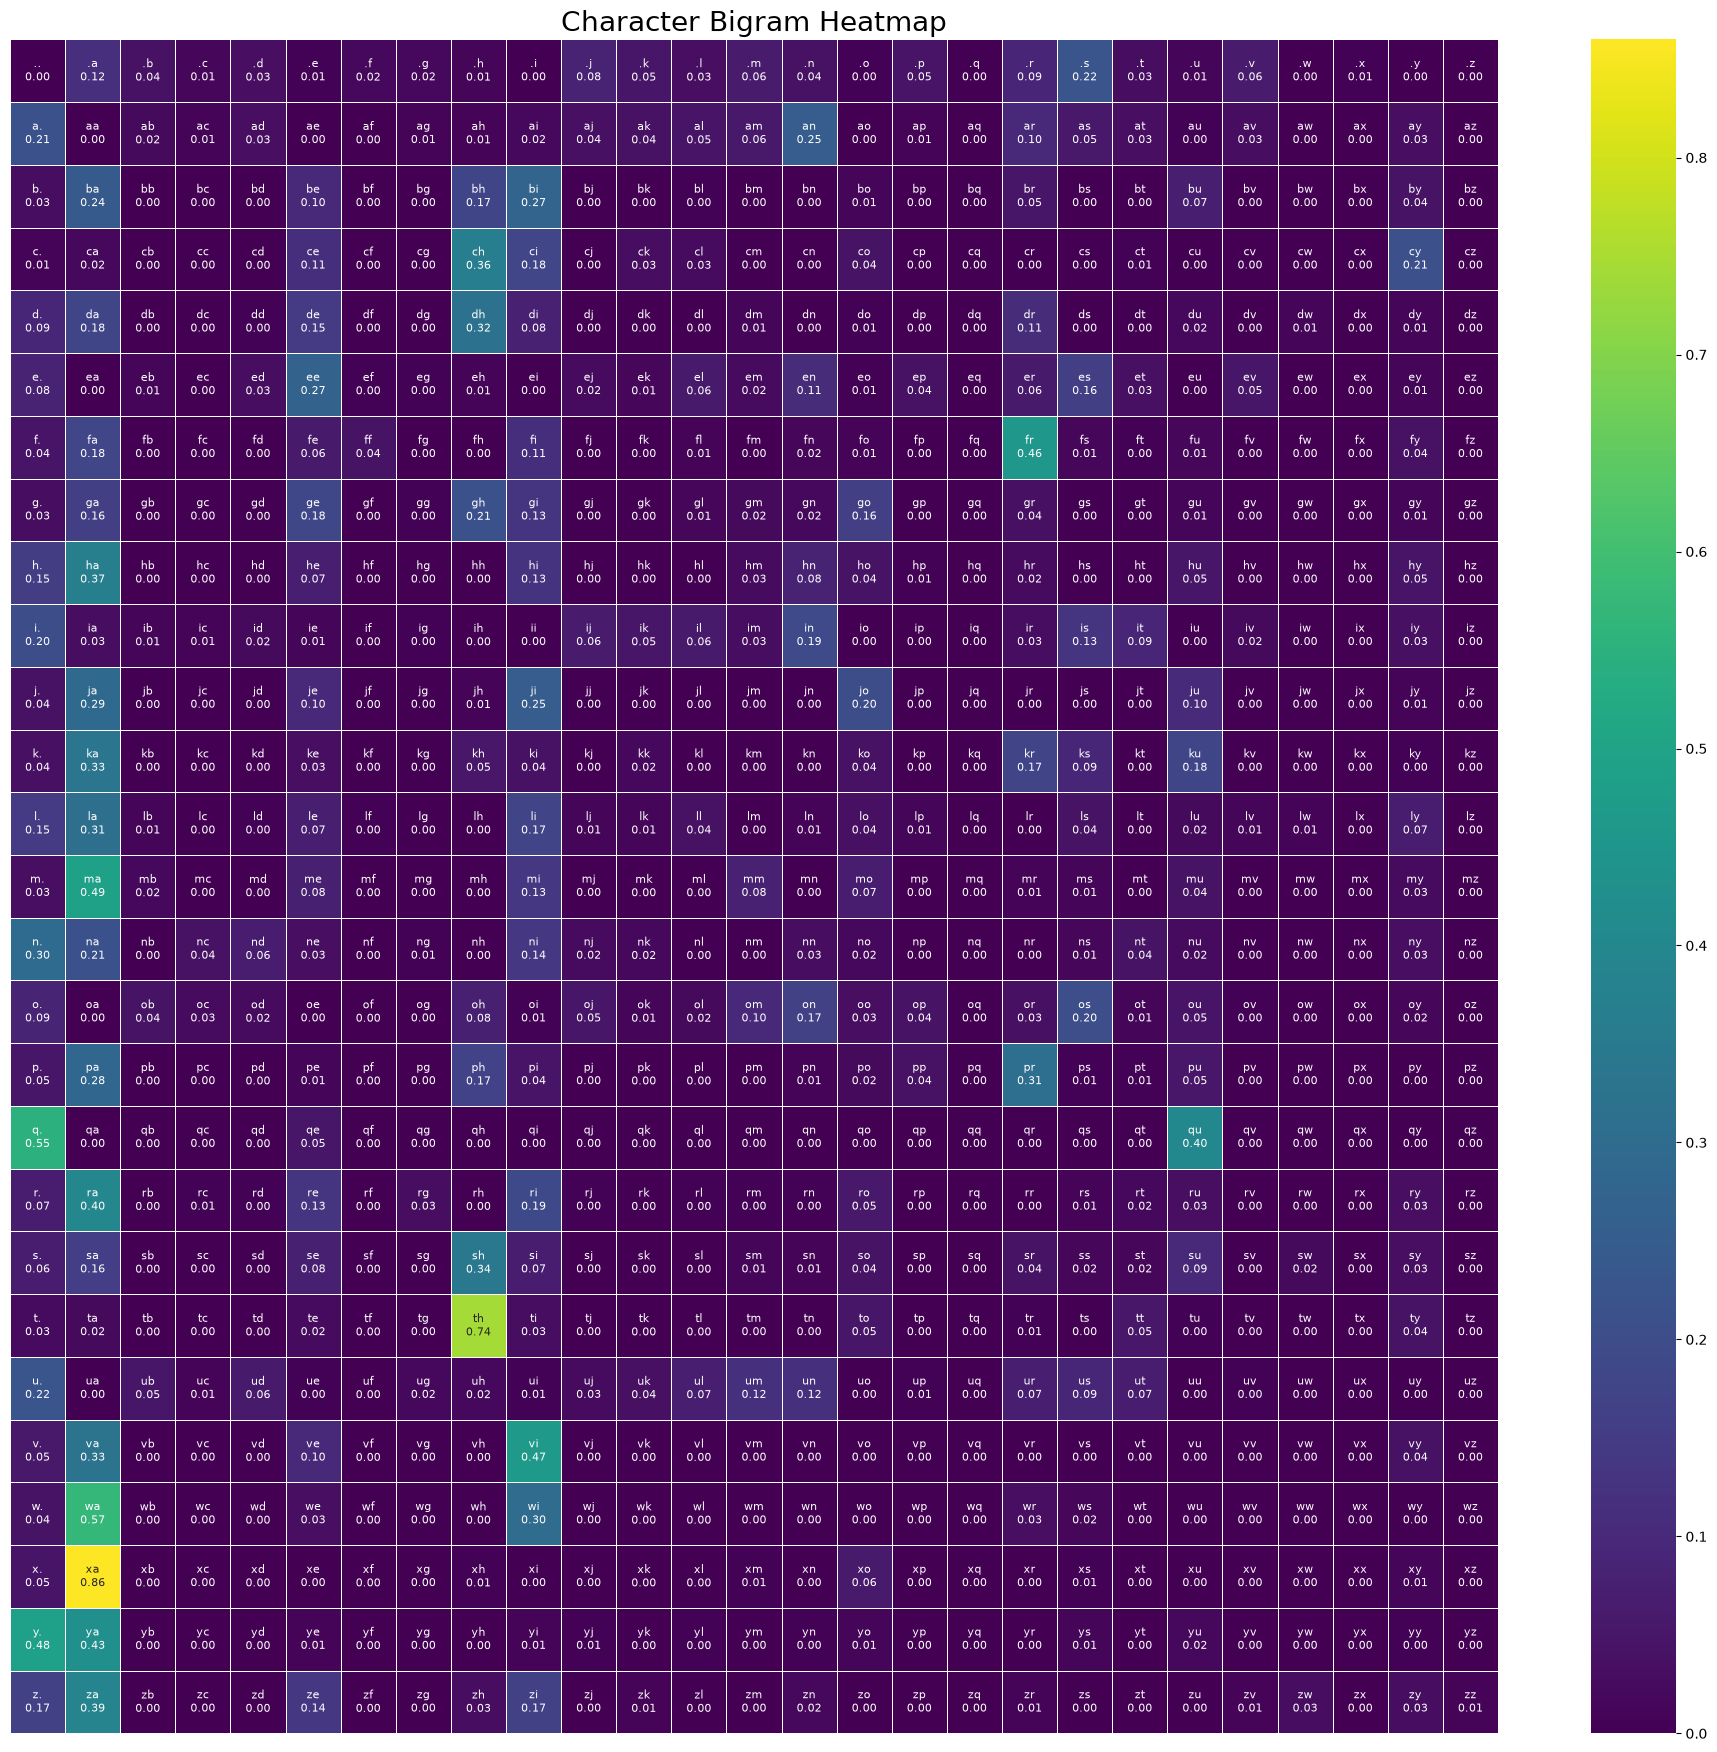

In [99]:

tensor_data = P.detach().cpu().numpy()

# Dummy itos mapping (e.g., 0='.', 1='a' through 26='z')
import string
itos = {0: '.'}
for i, char in enumerate(string.ascii_lowercase):
    itos[i+1] = char

# 2. Create the custom annotation array
# This will be a 27x27 array of strings formatted exactly how you want
annotations = np.empty((27, 27), dtype=object)

for i in range(27):
    for j in range(27):
        char_pair = f"{itos[i]}{itos[j]}"     # Example: "ab"
        val = tensor_data[i, j]               # Example: 0.4567...

        # Combine them with a newline (\n) and round the value to 2 decimals
        annotations[i, j] = f"{char_pair}\n{val:.2f}"

# 3. Set up the figure (made slightly larger to fit the extra text)
plt.figure(figsize=(24, 22))

# 4. Plot the heatmap
sns4.heatmap(tensor_data,
            annot=annotations,
            fmt="",                 # IMPORTANT: Must be empty string for custom text
            cmap="viridis",
            linewidths=0.5,
            xticklabels = False,
            yticklabels = False,
            annot_kws={"size": 8})  # Shrinks the font slightly to fit the boxes

# 5. Add labels
plt.title("Character Bigram Heatmap", fontsize=20)

plt.show()

Creating loss function for a perticular given name

In [100]:
given_name = 'akash'
name_prob = []
lh = torch.zeros(1,dtype=torch.float32)
g_name = '.' + given_name +'.'
for i1,i2 in zip(g_name,g_name[1:]):
    print(f"{i1}{i2} : {P[stoi[i1],stoi[i2]]:0.4f}")
    lh += P[stoi[i1],stoi[i2]].log()
#likelyhood
llh = lh.log()
print(f"negative log likely hood : {-lh.item():0.4f}")

.a : 0.1162
ak : 0.0389
ka : 0.3330
as : 0.0541
sh : 0.3440
h. : 0.1521
negative log likely hood : 12.3672


Building the same model with NN

In [ ]:
g = torch.Generator().manual_seed(1)
xis = [(stoi[x1],stoi[x2]) for name in names for x1,x2 in zip('.'+name+'.',name+'.')]
bi1 , bi2 = zip(*xis)
bi1 = torch.tensor(bi1)
bi2 = torch.tensor(bi2)
xi  = torch.nn.functional.one_hot(bi1, num_classes=27).float()
w = torch.randn([27,27],dtype=torch.float32,generator=g,requires_grad=True)


In [ ]:
for i in range(3000):
    logits = xi @ w
    count = logits.exp()
    prob = count / count.sum(1,keepdim=True)
    loss = -prob[torch.arange(len(bi2)),bi2].log().mean()
    # setting grad to zero
    w.grad = None
    # back propogation
    loss.backward()
    # updating the values
    w.data += -50*w.grad
    print(f'loss : {loss.item()}')

loss : 2.1875758171081543
loss : 2.1875698566436768
loss : 2.187563896179199
loss : 2.1875579357147217
loss : 2.187551975250244
loss : 2.1875462532043457
loss : 2.187540292739868
loss : 2.1875343322753906
loss : 2.187528610229492
loss : 2.1875228881835938
loss : 2.1875171661376953
loss : 2.1875112056732178
loss : 2.1875057220458984
loss : 2.187499523162842
loss : 2.1874940395355225
loss : 2.187488317489624
loss : 2.1874825954437256
loss : 2.1874771118164062
loss : 2.187471389770508
loss : 2.1874656677246094
loss : 2.18746018409729
loss : 2.1874544620513916
loss : 2.1874489784240723
loss : 2.187443256378174
loss : 2.1874377727508545
loss : 2.187432289123535
loss : 2.1874265670776367
loss : 2.1874210834503174
loss : 2.187415838241577
loss : 2.187410354614258
loss : 2.1874046325683594
loss : 2.187399387359619
loss : 2.187394142150879
loss : 2.1873884201049805
loss : 2.1873831748962402
loss : 2.187377691268921
loss : 2.1873724460601807
loss : 2.1873672008514404
loss : 2.187361717224121
los

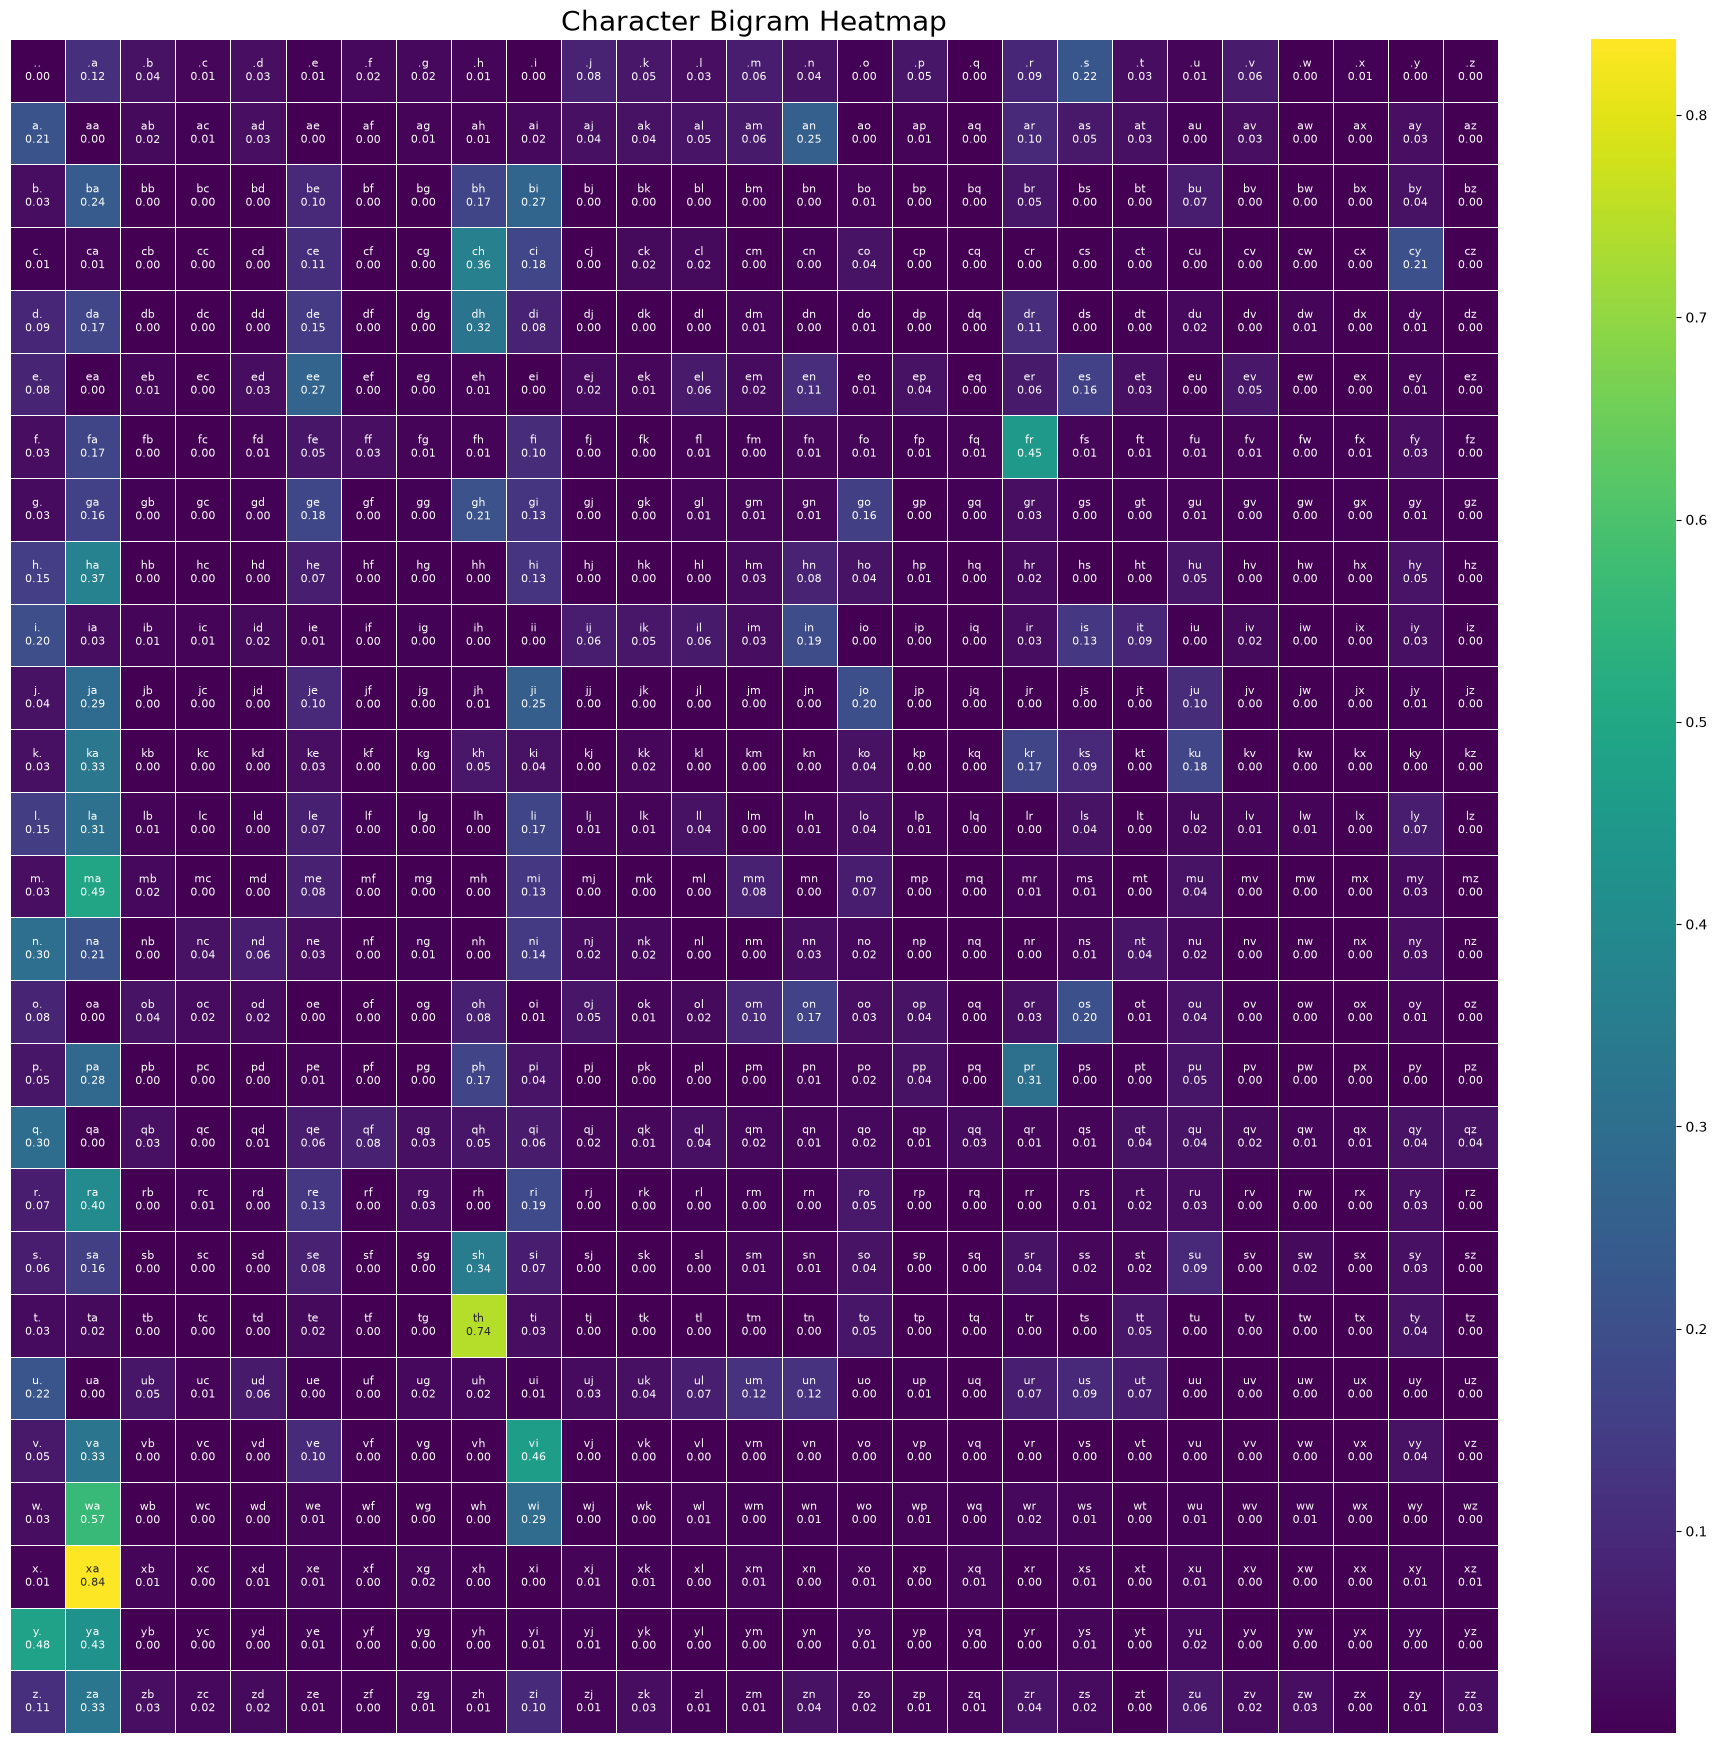

In [106]:
nl_prob = w.exp()
nl_prob = nl_prob/nl_prob.sum(1,keepdim=True)
tensor_data = nl_prob.detach().cpu().numpy()

# Dummy itos mapping (e.g., 0='.', 1='a' through 26='z')
import string
itos = {0: '.'}
for i, char in enumerate(string.ascii_lowercase):
    itos[i+1] = char

# 2. Create the custom annotation array
# This will be a 27x27 array of strings formatted exactly how you want
annotations = np.empty((27, 27), dtype=object)

for i in range(27):
    for j in range(27):
        char_pair = f"{itos[i]}{itos[j]}"     # Example: "ab"
        val = tensor_data[i, j]               # Example: 0.4567...

        # Combine them with a newline (\n) and round the value to 2 decimals
        annotations[i, j] = f"{char_pair}\n{val:.2f}"

# 3. Set up the figure (made slightly larger to fit the extra text)
plt.figure(figsize=(24, 22))

# 4. Plot the heatmap
sns4.heatmap(tensor_data,
            annot=annotations,
            fmt="",                 # IMPORTANT: Must be empty string for custom text
            cmap="viridis",
            linewidths=0.5,
            xticklabels = False,
            yticklabels = False,
            annot_kws={"size": 8})  # Shrinks the font slightly to fit the boxes

# 5. Add labels
plt.title("Character Bigram Heatmap", fontsize=20)

plt.show()

Checking does both works same

In [ ]:
g = torch.Generator().manual_seed(1)

for i in range(10):
  # Names prioducing from counting model
  sample_name_count = []
  n = 0
  while True:
    sample_n = torch.multinomial(P[n],num_samples=1,replacement=True,generator=g)
    n = sample_n.item()
    if n==0:
      break
    sample_name_count.append(itos[n])
  print(f"count{i}: {''.join(sample_name_count)}")

      

count0: ana
count1: rig
count2: ria
count3: sh
count4: s
count5: jarorsun
count6: depabimarari
count7: ri
count8: jely
count9: kan


In [128]:
g = torch.Generator().manual_seed(1)
for i in range(10):
  # Names prioducing from counting model
  sample_name_nn = []
  nl_prob = w.exp()
  nl_prob = nl_prob/nl_prob.sum(1,keepdim=True)
  while True:
    sample_n = torch.multinomial(nl_prob[n],num_samples=1,replacement=True,generator=g)
    n = sample_n.item()
    if n==0:
      break
    sample_name_nn.append(itos[n])
  print(f"count{i}: {''.join(sample_name_nn)}")

count0: ana
count1: rig
count2: ria
count3: sh
count4: s
count5: jarorsun
count6: depabimarari
count7: ri
count8: jely
count9: kan


In [138]:
a = [[1,2,3],[4,5,6]]
a = torch.tensor(a)
print(a[1,2])

tensor(6)
